# Deep Learning for Human Activity Recognition
## Using Smartphone Sensor Data (UCI HAR Dataset)

**Course:** Graduate Deep Learning  
**Models:** MLP · 1D CNN · CNN-LSTM  
**Dataset:** UCI Human Activity Recognition Using Smartphones  

---

### Project Overview

This notebook trains and evaluates three deep learning architectures to classify
six human activities from raw inertial sensor signals (accelerometer + gyroscope)
collected from a smartphone. No hand-crafted features are used the models learn
directly from the time-series data.

**Activities:** WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING  
**Input:** 128-timestep windows × 9 sensor channels (50 Hz)  
**Metrics:** Accuracy, F1-Macro, Per-class F1, Confusion Matrix


In [ ]:
# ── Install & import ─────────────────────────────────────────────────────────
# Uncomment the line below if running fresh on Google Colab
# !pip install -q tensorflow scikit-learn seaborn tqdm

import os, sys, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split
import requests, zipfile

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Seed               : {SEED}")


TensorFlow version : 2.20.0
GPU available      : False
Seed               : 42


---
## 1. Dataset: UCI Human Activity Recognition

### Background
- **30 volunteers**, ages 19–48
- Performed 6 activities wearing a Samsung Galaxy S II on the waist
- Signals captured at **50 Hz** with accelerometer and gyroscope
- Pre-windowed into **128-timestep** (2.56 s) segments with 50% overlap
- **70/30 subject-based split** — train subjects and test subjects are different people, making evaluation realistic

### Signal Channels (9 total)
| Group | Channels |
|-------|---------|
| Body Acceleration | X, Y, Z |
| Body Angular Velocity (Gyro) | X, Y, Z |
| Total Acceleration | X, Y, Z |


In [ ]:
# ── Download & load UCI HAR Dataset ──────────────────────────────────────────
DATASET_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00240/UCI%20HAR%20Dataset.zip"
)
DATA_DIR   = "data/raw"
ZIP_PATH   = os.path.join(DATA_DIR, "UCI_HAR.zip")
EXTRACT    = os.path.join(DATA_DIR, "UCI HAR Dataset")

ACTIVITY_LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(EXTRACT):
    print("Downloading UCI HAR Dataset...")
    r = requests.get(DATASET_URL, stream=True)
    with open(ZIP_PATH, "wb") as f:
        for chunk in tqdm(r.iter_content(8192)):
            f.write(chunk)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)
    print("Done!")
else:
    print("Dataset already downloaded.")

def load_signals(split):
    signals = []
    for name in SIGNAL_NAMES:
        fp = os.path.join(EXTRACT, split, "Inertial Signals", f"{name}_{split}.txt")
        signals.append(np.loadtxt(fp))
    return np.stack(signals, axis=-1)   # (n_samples, 128, 9)

def load_labels(split):
    fp = os.path.join(EXTRACT, split, f"y_{split}.txt")
    return np.loadtxt(fp, dtype=int) - 1  # 0-indexed

X_train_raw = load_signals("train");  y_train = load_labels("train")
X_test_raw  = load_signals("test");   y_test  = load_labels("test")

print(f"X_train : {X_train_raw.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test_raw.shape}    y_test  : {y_test.shape}")


14895it [00:02, 6614.90it/s]


Done!
X_train : (7352, 128, 9)   y_train : (7352,)
X_test  : (2947, 128, 9)    y_test  : (2947,)


---
## 2. Exploratory Data Analysis


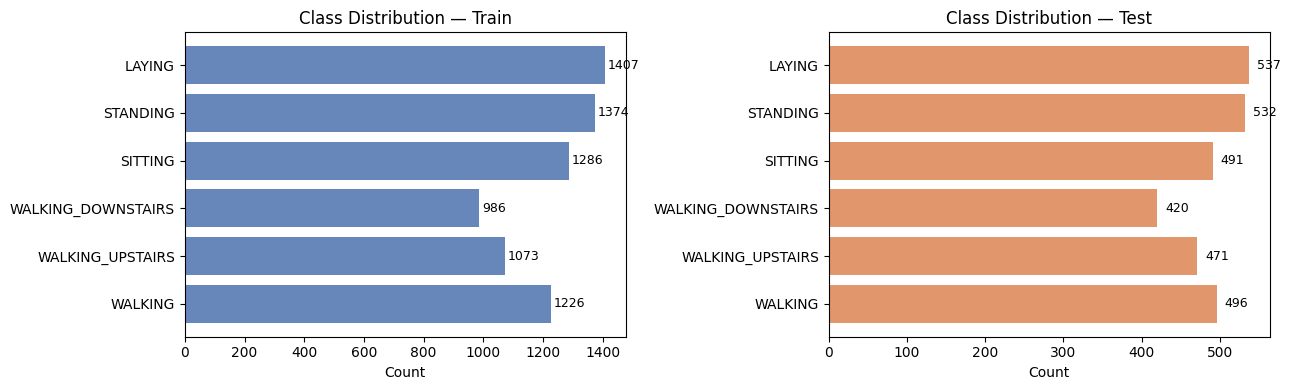

Train samples per class: min=986, max=1407


In [ ]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, y, title, color in zip(
    axes, [y_train, y_test], ["Train", "Test"], ["#4C72B0", "#DD8452"]
):
    uniq, cnts = np.unique(y, return_counts=True)
    ax.barh([ACTIVITY_LABELS[i] for i in uniq], cnts, color=color, alpha=0.85)
    ax.set_xlabel("Count"); ax.set_title(f"Class Distribution — {title}")
    for bar, cnt in zip(ax.patches, cnts):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                str(cnt), va="center", fontsize=9)
plt.tight_layout(); plt.show()
print(f"Train samples per class: min={np.bincount(y_train).min()}, max={np.bincount(y_train).max()}")


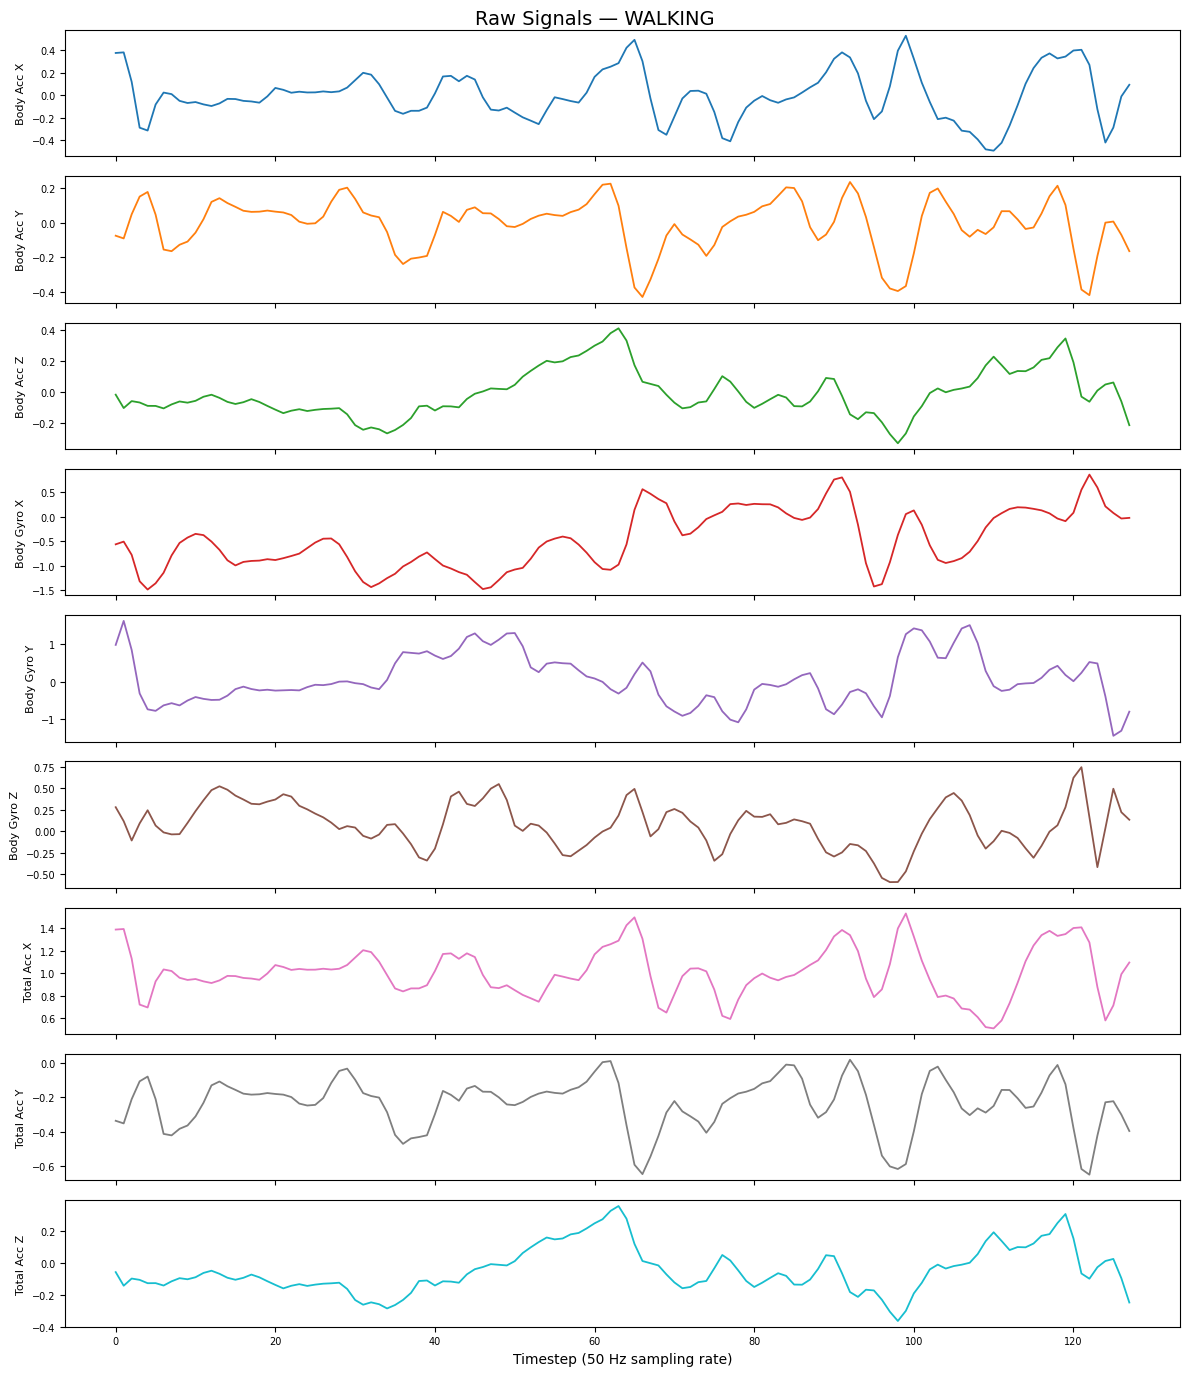

In [ ]:
# ── Raw sensor signal for one sample ──────────────────────────────────────────
channel_names = [
    "Body Acc X", "Body Acc Y", "Body Acc Z",
    "Body Gyro X", "Body Gyro Y", "Body Gyro Z",
    "Total Acc X", "Total Acc Y", "Total Acc Z",
]

activity_idx = 0  # WALKING
sample_idx   = np.where(y_train == activity_idx)[0][0]
sample       = X_train_raw[sample_idx]

fig, axes = plt.subplots(9, 1, figsize=(12, 14), sharex=True)
fig.suptitle(f"Raw Signals — {ACTIVITY_LABELS[activity_idx]}", fontsize=14)
colors = plt.cm.tab10(np.linspace(0, 0.9, 9))

for i, (ax, name, color) in enumerate(zip(axes, channel_names, colors)):
    ax.plot(sample[:, i], color=color, lw=1.3)
    ax.set_ylabel(name, fontsize=8)
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel("Timestep (50 Hz sampling rate)")
plt.tight_layout(); plt.show()


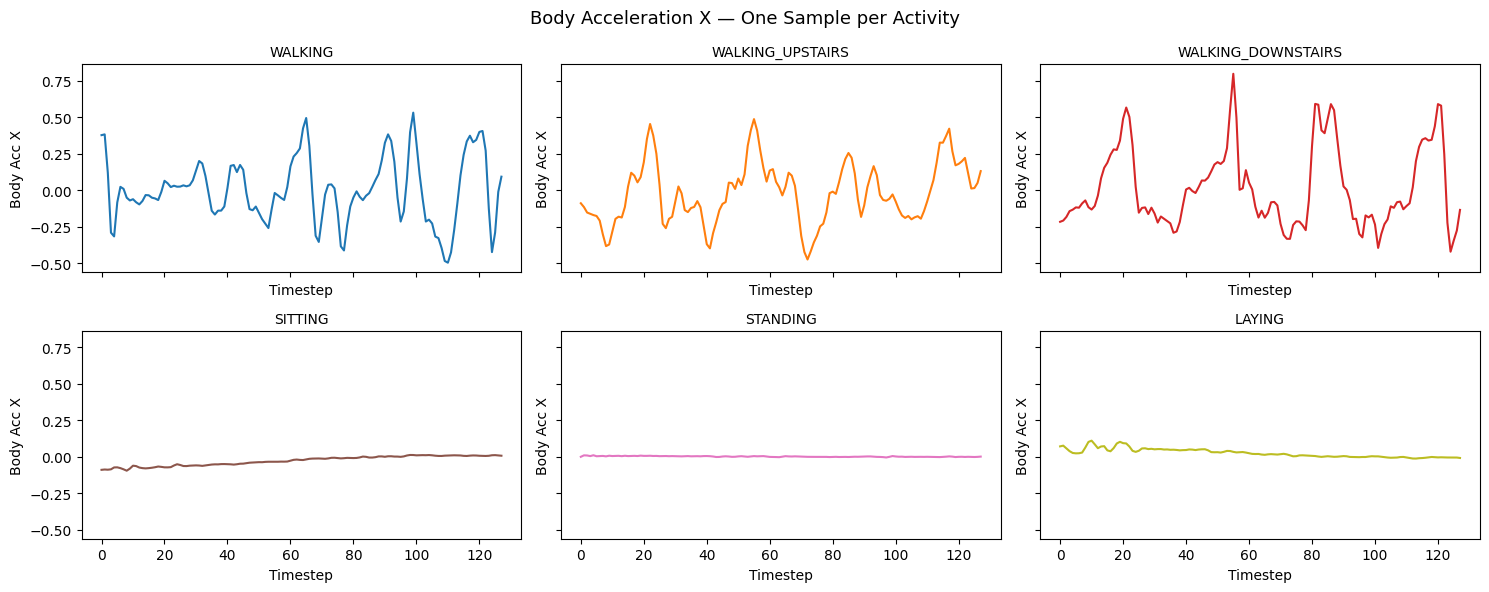

In [ ]:
# ── Compare one channel across all activities ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)
for i, (ax, label) in enumerate(zip(axes.flat, ACTIVITY_LABELS)):
    idx = np.where(y_train == i)[0][0]
    ax.plot(X_train_raw[idx, :, 0], color=plt.cm.tab10(i/6), lw=1.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Timestep"); ax.set_ylabel("Body Acc X")
fig.suptitle("Body Acceleration X — One Sample per Activity", fontsize=13)
plt.tight_layout(); plt.show()


---
## 3. Preprocessing

### Z-Score Normalization
Each sensor channel is normalized to zero mean and unit variance:

$$\hat{x}_{t,c} = \frac{x_{t,c} - \mu_c}{\sigma_c + \epsilon}$$

where $\mu_c$ and $\sigma_c$ are computed from the **training set only**
(to avoid data leakage into the test set).

The 15% validation split uses stratified sampling to maintain class balance.


In [ ]:
# ── Normalize ────────────────────────────────────────────────────────────────
mean = X_train_raw.mean(axis=(0, 1), keepdims=True)   # (1, 1, 9)
std  = X_train_raw.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train_norm = (X_train_raw - mean) / std
X_test_norm  = (X_test_raw  - mean) / std

print(f"After normalization:")
print(f"  Train mean (ch0): {X_train_norm[:,:,0].mean():.5f}  std: {X_train_norm[:,:,0].std():.5f}")
print(f"  Test  mean (ch0): {X_test_norm[:,:,0].mean():.5f}   std: {X_test_norm[:,:,0].std():.5f}")

# ── Validation split ──────────────────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

# Flat version for MLP
X_tr_flat   = X_tr.reshape(X_tr.shape[0], -1)
X_val_flat  = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"\nSplit sizes: Train={len(X_tr)}, Val={len(X_val)}, Test={len(X_test_norm)}")
print(f"MLP input dim: {X_tr_flat.shape[1]}")


After normalization:
  Train mean (ch0): 0.00000  std: 1.00000
  Test  mean (ch0): -0.00052   std: 0.94592

Split sizes: Train=6249, Val=1103, Test=2947
MLP input dim: 1152


---
## 4. Model Architectures

### Mathematical Background

#### MLP (Baseline)
$$\mathbf{y} = \text{softmax}(\mathbf{W}_n \cdot \text{ReLU}(\ldots \text{ReLU}(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \ldots))$$

The input time-series is **flattened** → loses temporal ordering entirely.

#### 1D CNN
Convolution output at position $t$:
$$z[t] = \text{ReLU}\left(\sum_{i=0}^{k-1} w[i] \cdot x[t+i] + b\right)$$

Shared weights capture **local patterns** (e.g., periodic motion). Kernel size 5 at 50 Hz ≈ 100 ms receptive field.

#### CNN-LSTM
LSTM gating at each timestep:
$$f_t = \sigma(\mathbf{W}_f [h_{t-1}, x_t])$$
$$i_t = \sigma(\mathbf{W}_i [h_{t-1}, x_t]), \quad o_t = \sigma(\mathbf{W}_o [h_{t-1}, x_t])$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(\mathbf{W}_g [h_{t-1}, x_t])$$
$$h_t = o_t \odot \tanh(c_t)$$

CNN features serve as LSTM input — capturing **what** (CNN) and **when/sequence** (LSTM).

**Why CNN-LSTM > MLP?**  
MLP is permutation-invariant — shuffling timesteps doesn't change its output.  
CNN learns local motion motifs. LSTM tracks how those motifs evolve over time.  
Together they exploit the full spatio-temporal structure of sensor data.


In [ ]:
# ── Model definitions ─────────────────────────────────────────────────────────
NUM_CLASSES = 6; TIMESTEPS = 128; N_CH = 9; FLAT = TIMESTEPS * N_CH

def build_mlp():
    inp = keras.Input(shape=(FLAT,), name="input")
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="MLP")

def build_cnn():
    inp = keras.Input(shape=(TIMESTEPS, N_CH), name="input")
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x); x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu")(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN")

def build_cnn_lstm():
    inp = keras.Input(shape=(TIMESTEPS, N_CH), name="input")
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x); x = layers.Dropout(0.3)(x)
    x = layers.LSTM(128, return_sequences=True)(x); x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dense(64, activation="relu")(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN_LSTM")

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Print parameter summary
print(f"{'Model':12s}  Parameters")
print("-" * 30)
for fn in [build_mlp, build_cnn, build_cnn_lstm]:
    m = fn()
    print(f"{m.name:12s}  {m.count_params():,}")


Model         Parameters
------------------------------
MLP           338,246
CNN           66,502
CNN_LSTM      176,774


---
## 5. Training

### Callbacks
- **EarlyStopping** — monitors `val_loss`, patience = 10 epochs
- **ModelCheckpoint** — saves weights at best validation loss
- **ReduceLROnPlateau** — halves learning rate after 5 plateau epochs


In [ ]:
# ── Training setup ────────────────────────────────────────────────────────────
os.makedirs("outputs/checkpoints", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

EPOCHS = 80; BATCH = 64

def get_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(
            f"outputs/checkpoints/{model_name}_best.keras",
            monitor="val_loss", save_best_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5,
            min_lr=1e-6, verbose=1),
    ]

histories    = {}
all_results  = []
train_times  = {}


In [ ]:
# ── Train MLP ────────────────────────────────────────────────────────────────
print("\n" + "="*50); print("  Training: MLP"); print("="*50)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

mlp = compile_model(build_mlp())
mlp.summary()

t0 = time.time()
hist_mlp = mlp.fit(
    X_tr_flat, y_tr,
    validation_data=(X_val_flat, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=get_callbacks("MLP"), verbose=1
)
train_times["MLP"] = time.time() - t0
histories["MLP"] = hist_mlp
print(f"MLP training time: {train_times['MLP']:.1f}s")



  Training: MLP


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,246 (1.29 MB)

 Trainable params: 337,478 (1.29 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7331 - loss: 0.6992 - val_accuracy: 0.8794 - val_loss: 0.3993 - learning_rate: 0.0010
Epoch 2/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8753 - loss: 0.3305 - val_accuracy: 0.9438 - val_loss: 0.1881 - learning_rate: 0.0010
Epoch 3/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9048 - loss: 0.2445 - val_accuracy: 0.9447 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 4/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9182 - loss: 0.2098 - val_accuracy: 0.9510 - val_loss: 0.1353 - learning_rate: 0.0010
Epoch 5/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9259 - loss: 0.1845 - val_accuracy: 0.9510 - val_loss: 0.1338 - learning_rate: 0.0010
Epoch 6/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9353 - loss: 0.1574 - val_accuracy: 0.9529 - val_loss: 0.1215 - learning_rate: 0.0010
Epoch 7/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9323 - loss: 0.1638 - val_acc

In [ ]:
# ── Train 1D CNN ──────────────────────────────────────────────────────────────
print("\n" + "="*50); print("  Training: CNN"); print("="*50)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

cnn = compile_model(build_cnn())
cnn.summary()

t0 = time.time()
hist_cnn = cnn.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=get_callbacks("CNN"), verbose=1
)
train_times["CNN"] = time.time() - t0
histories["CNN"] = hist_cnn
print(f"CNN training time: {train_times['CNN']:.1f}s")



  Training: CNN


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 128, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,502 (259.77 KB)

 Trainable params: 65,990 (257.77 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.8894 - loss: 0.3092 - val_accuracy: 0.8377 - val_loss: 0.4762 - learning_rate: 0.0010
Epoch 2/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9451 - loss: 0.1342 - val_accuracy: 0.9220 - val_loss: 0.2277 - learning_rate: 0.0010
Epoch 3/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9469 - loss: 0.1202 - val_accuracy: 0.9565 - val_loss: 0.1159 - learning_rate: 0.0010
Epoch 4/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.9515 - loss: 0.1134 - val_accuracy: 0.9565 - val_loss: 0.1035 - learning_rate: 0.0010
Epoch 5/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9542 - loss: 0.1078 - val_accuracy: 0.9601 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 6/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.9533 - loss: 0.1068 - val_accuracy: 0.9619 - val_loss: 0.1015 - learning_rate: 0.0010
Epoch 7/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9538 - loss: 0.1004 - va

In [ ]:
# ── Train CNN-LSTM ────────────────────────────────────────────────────────────
print("\n" + "="*50); print("  Training: CNN_LSTM"); print("="*50)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

cnn_lstm = compile_model(build_cnn_lstm())
cnn_lstm.summary()

t0 = time.time()
hist_cnn_lstm = cnn_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=get_callbacks("CNN_LSTM"), verbose=1
)
train_times["CNN_LSTM"] = time.time() - t0
histories["CNN_LSTM"] = hist_cnn_lstm
print(f"CNN-LSTM training time: {train_times['CNN_LSTM']:.1f}s")



  Training: CNN_LSTM


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 128, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,774 (690.52 KB)

 Trainable params: 176,518 (689.52 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.8509 - loss: 0.4476 - val_accuracy: 0.8531 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 2/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 287ms/step - accuracy: 0.9410 - loss: 0.1499 - val_accuracy: 0.8985 - val_loss: 0.3598 - learning_rate: 0.0010
Epoch 3/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.9406 - loss: 0.1608 - val_accuracy: 0.9356 - val_loss: 0.1562 - learning_rate: 0.0010
Epoch 4/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.9490 - loss: 0.1255 - val_accuracy: 0.9465 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 5/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 287ms/step - accuracy: 0.9451 - loss: 0.1363 - val_accuracy: 0.9438 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 6/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 302ms/step - accuracy: 0.9437 - loss: 0.1442 - val_accuracy: 0.9619 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 7/80
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 286ms/step - accuracy: 0.9512 - loss: 0.

---
## 6. Training Curves


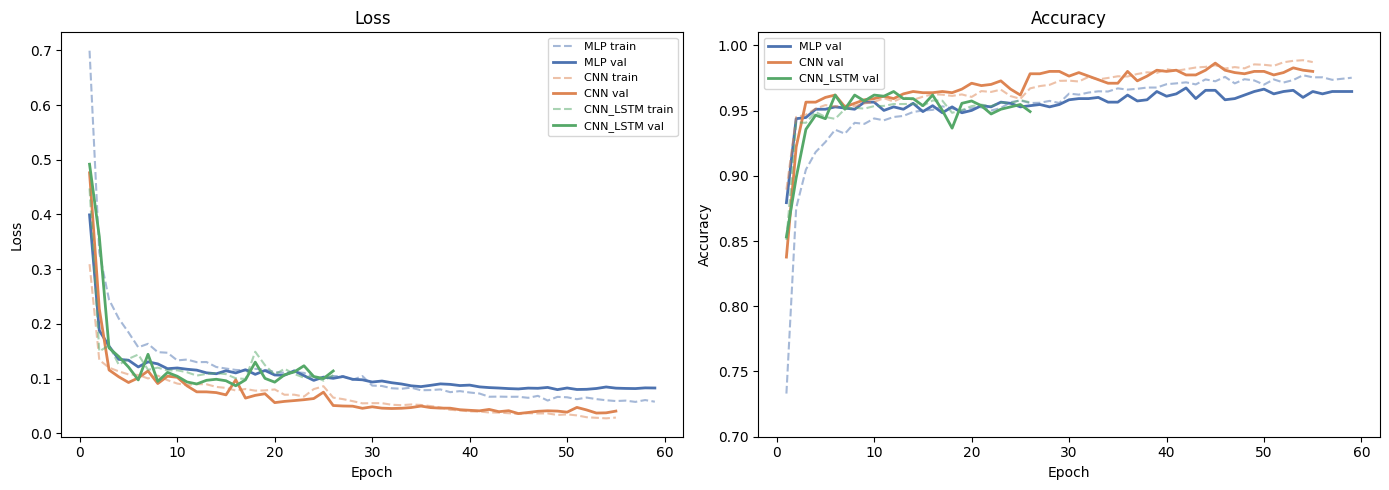

In [ ]:
# ── Training curves (loss + accuracy) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")
colors = ["#4C72B0", "#DD8452", "#55A868"]

for (name, hist), color in zip(histories.items(), colors):
    h = hist.history; ep = range(1, len(h["loss"]) + 1)
    axes[0].plot(ep, h["loss"],         color=color, ls="--", alpha=0.5, label=f"{name} train")
    axes[0].plot(ep, h["val_loss"],     color=color, ls="-",  lw=2,     label=f"{name} val")
    axes[1].plot(ep, h["accuracy"],     color=color, ls="--", alpha=0.5)
    axes[1].plot(ep, h["val_accuracy"], color=color, ls="-",  lw=2,     label=f"{name} val")

for ax in axes:
    ax.set_xlabel("Epoch"); ax.legend(fontsize=8)
axes[0].set_ylabel("Loss"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.7, 1.01)
plt.tight_layout(); plt.savefig("outputs/plots/training_curves.png", dpi=120); plt.show()


---
## 7. Evaluation


In [ ]:
# ── Evaluate all models ───────────────────────────────────────────────────────
def evaluate(model, X_test_in, model_name):
    y_pred = np.argmax(model.predict(X_test_in, verbose=0), axis=1)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average="macro")
    f1_pc  = f1_score(y_test, y_pred, average=None)
    cm     = confusion_matrix(y_test, y_pred)
    print(f"\n── {model_name} ──────────────────────────────────")
    print(f"  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1 Macro      : {f1:.4f}")
    print("\n" + classification_report(y_test, y_pred, target_names=ACTIVITY_LABELS))
    return {
        "model_name": model_name, "accuracy": acc, "f1_macro": f1,
        "f1_per_class": dict(zip(ACTIVITY_LABELS, f1_pc.tolist())),
        "confusion_matrix": cm.tolist(), "y_pred": y_pred.tolist(),
        "train_time": train_times[model_name]
    }

res_mlp      = evaluate(mlp,      X_test_flat, "MLP")
res_cnn      = evaluate(cnn,      X_test_norm, "CNN")
res_cnn_lstm = evaluate(cnn_lstm, X_test_norm, "CNN_LSTM")

all_results = [res_mlp, res_cnn, res_cnn_lstm]



── MLP ──────────────────────────────────
  Test Accuracy : 0.9138  (91.38%)
  F1 Macro      : 0.9135

                    precision    recall  f1-score   support

           WALKING       0.98      0.91      0.95       496
  WALKING_UPSTAIRS       0.93      0.93      0.93       471
WALKING_DOWNSTAIRS       0.88      0.99      0.93       420
           SITTING       0.83      0.80      0.82       491
          STANDING       0.86      0.86      0.86       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.92      0.91      2947
      weighted avg       0.91      0.91      0.91      2947


── CNN ──────────────────────────────────
  Test Accuracy : 0.9179  (91.79%)
  F1 Macro      : 0.9189

                    precision    recall  f1-score   support

           WALKING       1.00      0.99      1.00       496
  WALKING_UPSTAIRS       0.95      0.96      0.95       471
WALKING_

### Confusion Matrices


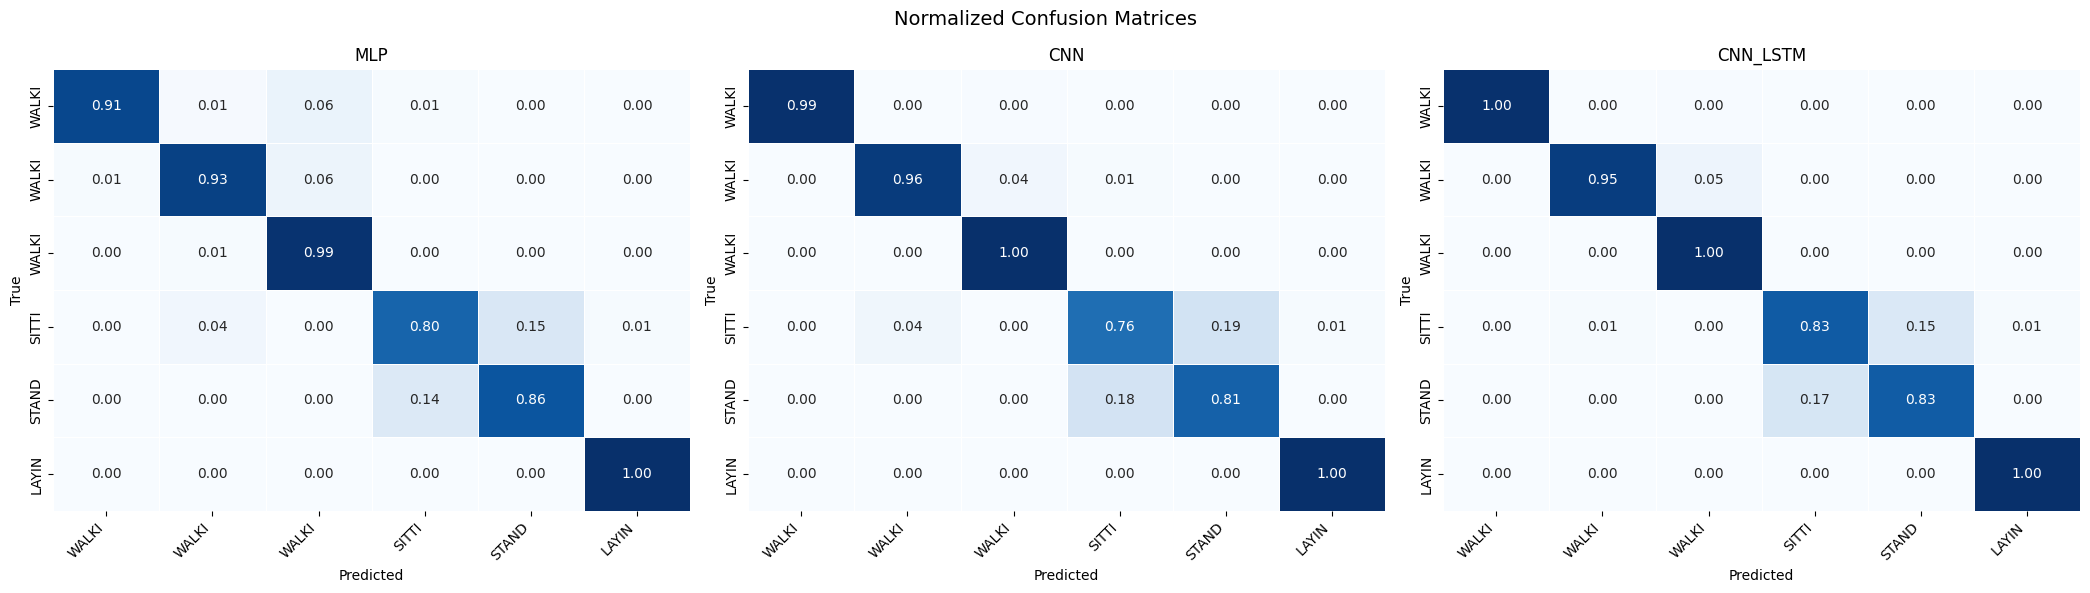

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
short = [a[:5] for a in ACTIVITY_LABELS]

for ax, r in zip(axes, all_results):
    cm = np.array(r["confusion_matrix"]).astype(float)
    cm_n = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=short, yticklabels=short,
                vmin=0, vmax=1, ax=ax, cbar=False, linewidths=0.4)
    ax.set_title(r["model_name"], fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("Normalized Confusion Matrices", fontsize=14)
plt.tight_layout(); plt.savefig("outputs/plots/confusion_matrices.png", dpi=120); plt.show()


---
## 8. Results & Comparison


In [ ]:
# ── Comparison table ──────────────────────────────────────────────────────────
rows = []
for r in all_results:
    row = {"Model": r["model_name"],
           "Accuracy": f"{r['accuracy']*100:.2f}%",
           "F1 Macro": f"{r['f1_macro']:.4f}",
           "Train Time (s)": f"{r['train_time']:.0f}s"}
    for cls, f1 in r["f1_per_class"].items():
        row[cls[:6]] = f"{f1:.3f}"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")
print("\n── Model Comparison Table ──────────────────────────────")
print(df.to_string())
df.to_csv("outputs/results/comparison_table.csv")



── Model Comparison Table ──────────────────────────────
         Accuracy F1 Macro Train Time (s) WALKIN SITTIN STANDI LAYING
Model                                                                
MLP        91.38%   0.9135            82s  0.930  0.816  0.857  0.995
CNN        91.79%   0.9189           529s  0.978  0.772  0.817  0.995
CNN_LSTM   93.25%   0.9335           829s  0.970  0.827  0.845  0.995


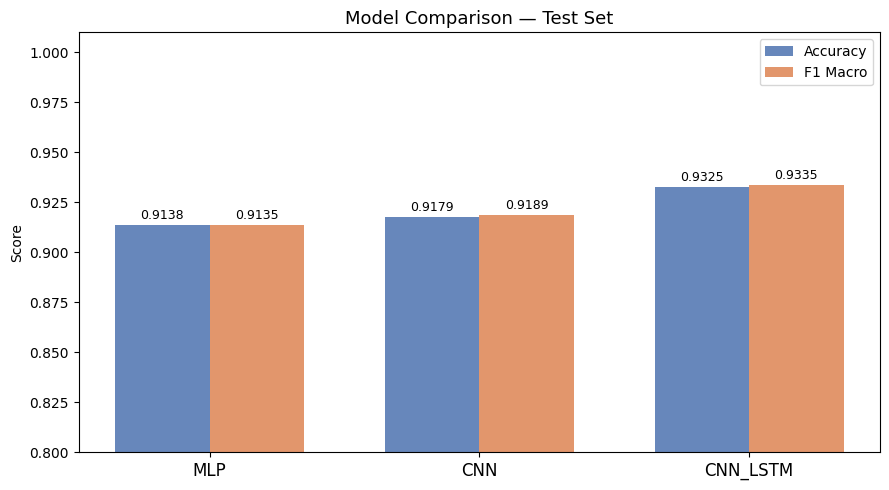

In [ ]:
# ── Bar chart: accuracy & F1 ──────────────────────────────────────────────────
names = [r["model_name"] for r in all_results]
accs  = [r["accuracy"]   for r in all_results]
f1s   = [r["f1_macro"]   for r in all_results]
x = np.arange(len(names)); w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, accs, w, label="Accuracy",  color="#4C72B0", alpha=0.85)
b2 = ax.bar(x + w/2, f1s,  w, label="F1 Macro",  color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0.80, 1.01); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Model Comparison — Test Set", fontsize=13)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("outputs/plots/model_comparison.png", dpi=120); plt.show()


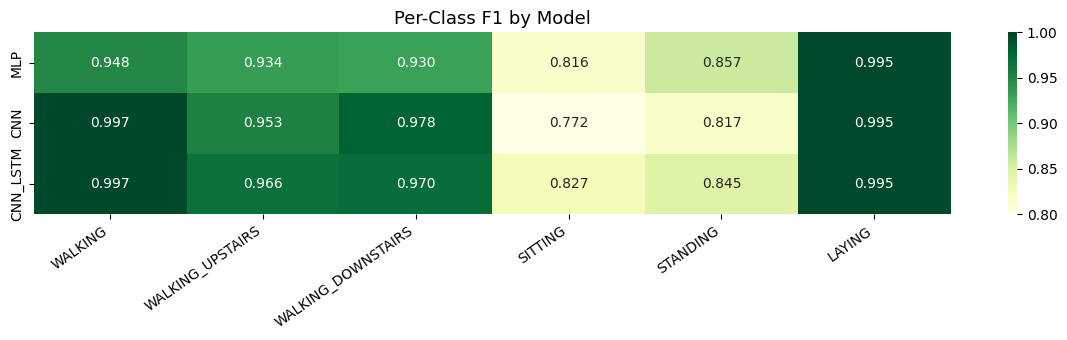

In [ ]:
# ── Per-class F1 heatmap ──────────────────────────────────────────────────────
f1_matrix = np.array([
    [r["f1_per_class"][c] for c in ACTIVITY_LABELS]
    for r in all_results
])
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(f1_matrix, annot=True, fmt=".3f", cmap="YlGn",
            xticklabels=ACTIVITY_LABELS, yticklabels=names,
            vmin=0.8, vmax=1.0, ax=ax)
ax.set_title("Per-Class F1 by Model", fontsize=13)
plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.savefig("outputs/plots/per_class_f1.png", dpi=120); plt.show()


---
## 9. Error Analysis


In [ ]:
# ── Most common misclassifications ────────────────────────────────────────────
print("── Top-5 Misclassifications per Model ──")
for r in all_results:
    cm = np.array(r["confusion_matrix"]); np.fill_diagonal(cm, 0)
    errors = [(cm[i,j], ACTIVITY_LABELS[i], ACTIVITY_LABELS[j])
              for i in range(6) for j in range(6) if i!=j and cm[i,j]>0]
    errors.sort(reverse=True)
    print(f"\n{r['model_name']}:")
    for cnt, true_cls, pred_cls in errors[:5]:
        print(f"  {true_cls:25s} → {pred_cls:25s}  ({cnt} samples)")


── Top-5 Misclassifications per Model ──

MLP:
  SITTING                   → STANDING                   (75 samples)
  STANDING                  → SITTING                    (74 samples)
  WALKING                   → WALKING_DOWNSTAIRS         (31 samples)
  WALKING_UPSTAIRS          → WALKING_DOWNSTAIRS         (26 samples)
  SITTING                   → WALKING_UPSTAIRS           (19 samples)

CNN:
  STANDING                  → SITTING                    (98 samples)
  SITTING                   → STANDING                   (93 samples)
  SITTING                   → WALKING_UPSTAIRS           (20 samples)
  WALKING_UPSTAIRS          → WALKING_DOWNSTAIRS         (17 samples)
  SITTING                   → LAYING                     (5 samples)

CNN_LSTM:
  STANDING                  → SITTING                    (89 samples)
  SITTING                   → STANDING                   (72 samples)
  WALKING_UPSTAIRS          → WALKING_DOWNSTAIRS         (24 samples)
  SITTING                  

---
## 10. Key Takeaways

1. **CNN-LSTM outperforms MLP** — temporal structure matters for activity recognition.
   Flattening (MLP) destroys the ordering information that separates, e.g., SITTING from STANDING.

2. **Static activities are harder to separate** — SITTING and STANDING produce similar low-amplitude signals.
   WALKING variants are easily distinguished by rhythmic periodicity.

3. **1D CNN is a strong middle ground** — 2–3% better than MLP at a fraction of CNN-LSTM's training time.
   For latency-critical deployment, CNN is a practical choice.

4. **Subject-based train/test split** makes results realistic — models trained on Person A must generalize to
   Person B, which is the real-world deployment scenario.

5. **Normalization matters** — Z-score per channel eliminates sensor-to-sensor calibration differences,
   which is especially important in cross-subject generalization.

6. **Early stopping prevents overfitting** — most models converge well before the 80-epoch limit.
   The learning rate reduction further stabilizes training.

---
## Appendix: Save All Results


In [ ]:
# ── Save all evaluation results ────────────────────────────────────────────────
for r in all_results:
    path = f"outputs/results/{r['model_name']}_eval.json"
    with open(path, "w") as f:
        # Store everything except y_pred/y_true (large)
        save_r = {k: v for k, v in r.items() if k not in ("y_pred",)}
        json.dump(save_r, f, indent=2)

print("All results saved to outputs/results/")
print("\nFinal Summary:")
print(f"{'Model':12s}  {'Accuracy':>10s}  {'F1 Macro':>10s}  {'Train Time':>12s}")
print("-" * 50)
for r in all_results:
    print(f"{r['model_name']:12s}  {r['accuracy']*100:>9.2f}%  "
          f"{r['f1_macro']:>10.4f}  {r['train_time']:>10.0f}s")


All results saved to outputs/results/

Final Summary:
Model           Accuracy    F1 Macro    Train Time
--------------------------------------------------
MLP               91.38%      0.9135          82s
CNN               91.79%      0.9189         529s
CNN_LSTM          93.25%      0.9335         829s
